**Decision tree**

**1.Data Preparation**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
df=pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


**2.EDA**

In [3]:
print(df.shape)

(908, 13)


In [4]:
print('column names:')
print(df.columns)

column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')


In [5]:
#check non null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
#missing values
missing_values=df.isnull().sum()
print('Missing values:')
print(missing_values)

Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [8]:
#check duplicate values
print('number of duplicate rows:',df.duplicated().sum())

number of duplicate rows: 1


In [9]:
#remove duplicate rows
df=df.drop_duplicates()
print(df.shape)

(907, 13)


In [10]:
#check inconsistance
# Display unique values in categorical columns
for column in df.select_dtypes(include='object').columns:
    print("\n", column)
    print(df[column].unique())


 sex
['Male' 'Female']

 cp
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']

 restecg
['lv hypertrophy' 'normal' 'st-t abnormality']

 exang
[False True 'FALSE' 'TURE']

 slope
['downsloping' 'flat' 'upsloping']

 thal
['fixed defect' 'normal' 'reversable defect']


In [11]:
#numerical values
df.describe().T[['min','max']]

,min,max
age,29.0,77.0
trestbps,0.0,200.0
chol,0.0,603.0
thalch,60.0,202.0
oldpeak,-2.6,6.2
num,0.0,4.0


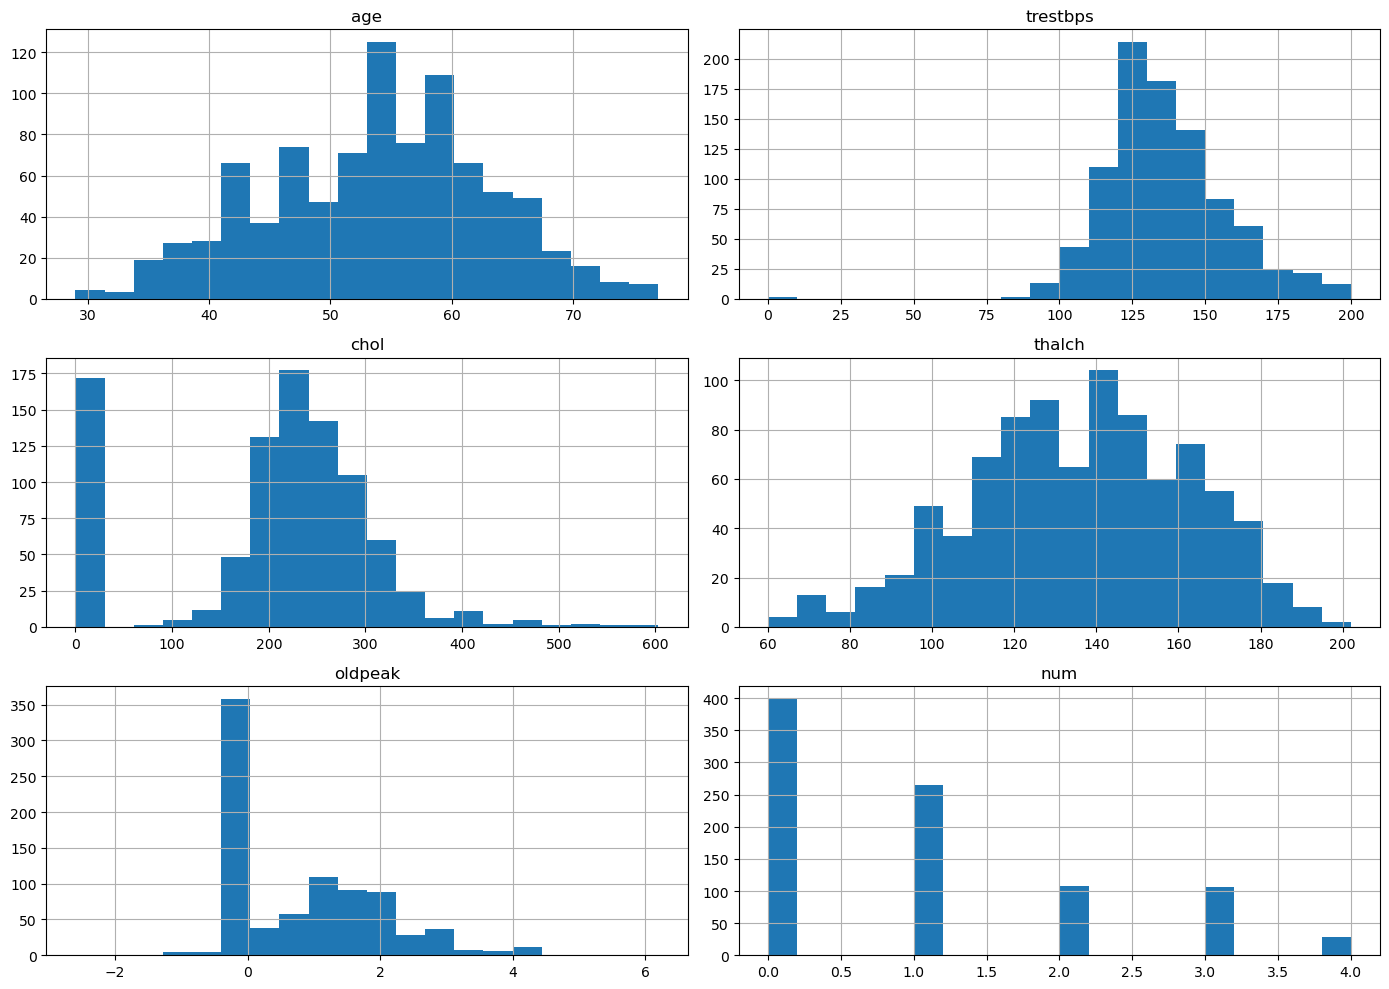

In [12]:
#histogram
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Plot histograms
df[numerical_cols].hist(figsize=(14, 10), bins=20)

plt.tight_layout()
plt.show()

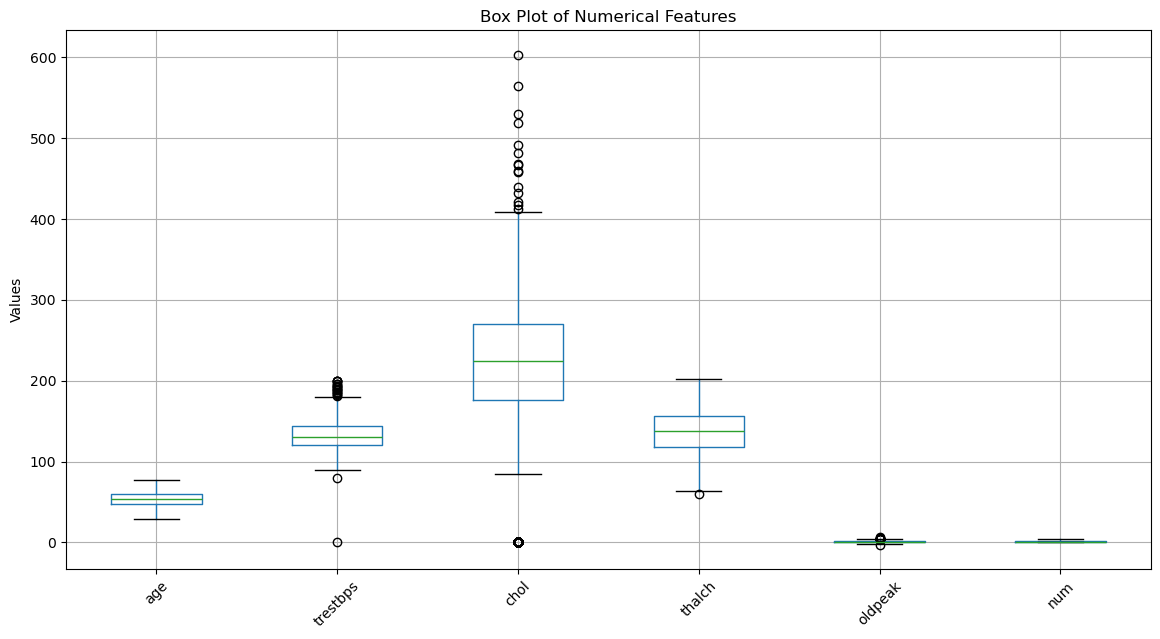

In [13]:
#Box plot
plt.figure(figsize=(14, 7))
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

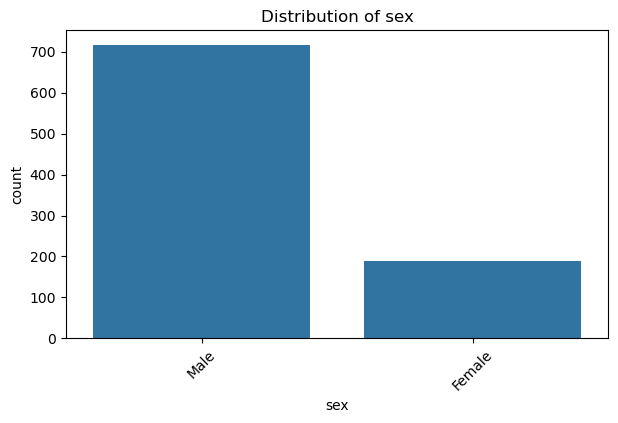

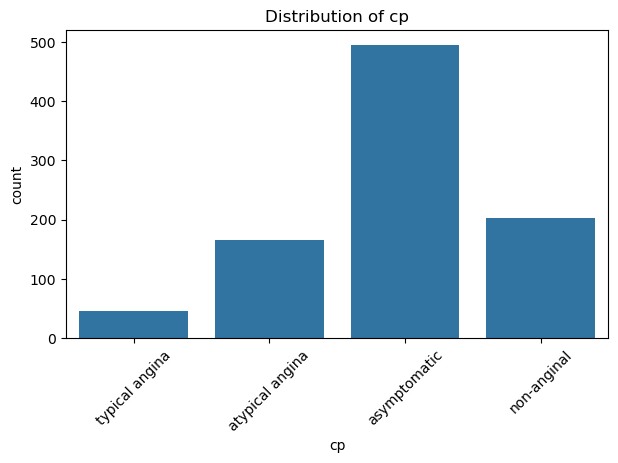

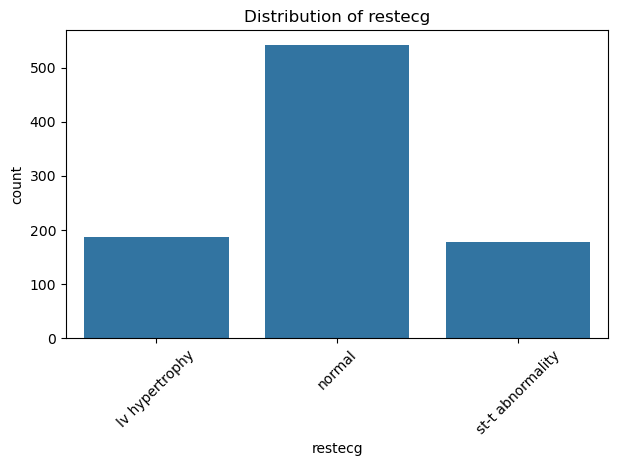

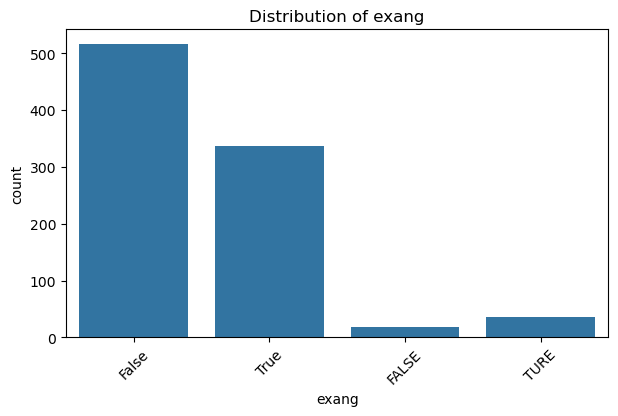

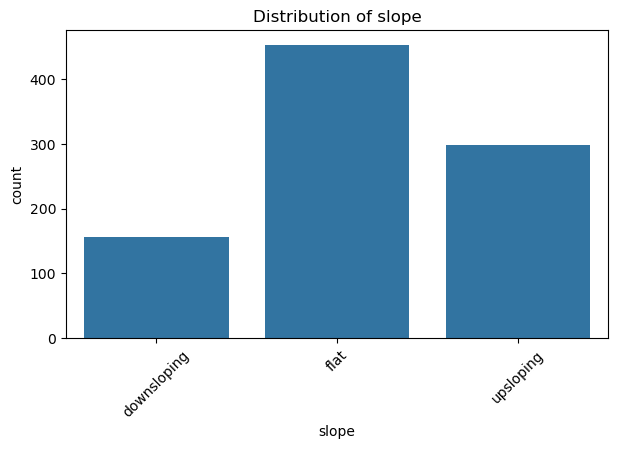

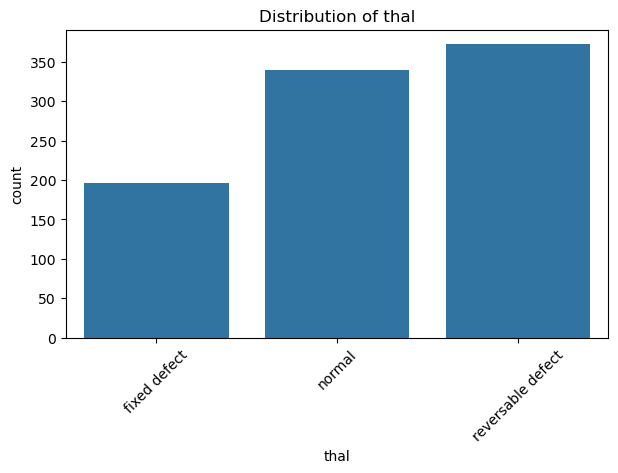

In [14]:
categorical_cols = df.select_dtypes(include='object').columns
for column in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=df[column])
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.show()

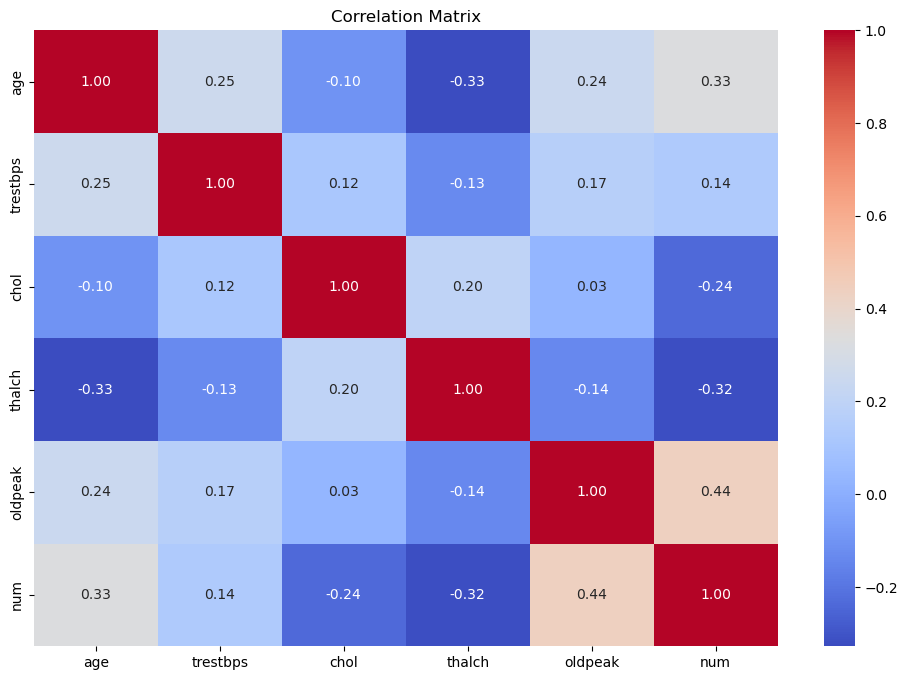

In [15]:
# Calculate correlation
correlation = df[numerical_cols].corr()

# Display correlation matrix
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
# Display correlations greater than 0.5 or less than -0.5
strong_corr = correlation[
    (correlation > 0.5) | (correlation < -0.5)
]
strong_corr

,age,trestbps,chol,thalch,oldpeak,num
age,1.0,NaN,NaN,NaN,NaN,NaN
trestbps,NaN,1.0,NaN,NaN,NaN,NaN
chol,NaN,NaN,1.0,NaN,NaN,NaN
thalch,NaN,NaN,NaN,1.0,NaN,NaN
oldpeak,NaN,NaN,NaN,NaN,1.0,NaN
num,NaN,NaN,NaN,NaN,NaN,1.0


**3.Feature Engineering**

In [39]:
#separate feature values
X=df.drop('num',axis=1)
y=df['num']


In [40]:
print('features:')
print(X.columns.tolist())

features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal']


In [42]:
print('\nTarget:')
print('num')


Target:
num


identify num and cat data

In [44]:
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns
categorical_cols = X.select_dtypes(
    include=['object', 'bool']
).columns
print("Numerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Categorical columns:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


convert cat data into string

In [47]:
for column in categorical_cols:
    X[column]=X[column].astype(str)

handle missing values

In [48]:
# Numerical columns
numerical_imputer = SimpleImputer(
    strategy='median'
)
X[numerical_cols] = numerical_imputer.fit_transform(
    X[numerical_cols]
)

In [49]:
# Categorical columns
categorical_imputer = SimpleImputer(
    strategy='most_frequent'
)
X[categorical_cols] = categorical_imputer.fit_transform(
    X[categorical_cols]
)

One-Hot Encoding

In [50]:
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)
encoded_data = encoder.fit_transform(
    X[categorical_cols]
)
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

In [51]:
X = X.drop(columns=categorical_cols)
X = pd.concat(
    [X, encoded_df],
    axis=1
)
X.head()

,age,trestbps,chol,thalch,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_False,exang_TURE,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,41.0,135.0,203.0,132.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,57.0,140.0,192.0,148.0,0.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,52.0,118.0,186.0,190.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,57.0,110.0,201.0,126.0,1.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Final dataset

In [52]:
print("Final shape:", X.shape)
print(
    "Total missing values:",
    X.isnull().sum().sum()
)

Final shape: (907, 19)
Total missing values: 0


**4.Decision Tree Classification**

split dataset

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (725, 19)
Testing data: (182, 19)


In [56]:
dt_model=DecisionTreeClassifier(
    random_state=42
)

In [57]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred=dt_model.predict(X_test)
print('Predictions:')
print(y_pred[:10])

Predictions:
[3 2 2 0 0 1 0 1 0 0]


In [67]:
#accuracy
accuracy=accuracy_score(
    y_test,
    y_pred
)
print('Accuracy:',accuracy)

Accuracy: 0.5


In [69]:
recall=recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)
print('recall:',recall)

recall: 0.5


In [70]:
precision=precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)
print('precision:',precision)

precision: 0.5078181078181078


In [71]:
f1=f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)
print('f1:',f1)

f1: 0.5020104989492744


In [74]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.71      0.71      0.71        80
           1       0.42      0.43      0.43        53
           2       0.15      0.18      0.16        22
           3       0.43      0.29      0.34        21
           4       0.17      0.17      0.17         6

    accuracy                           0.50       182
   macro avg       0.37      0.36      0.36       182
weighted avg       0.51      0.50      0.50       182



Confusion Matrix

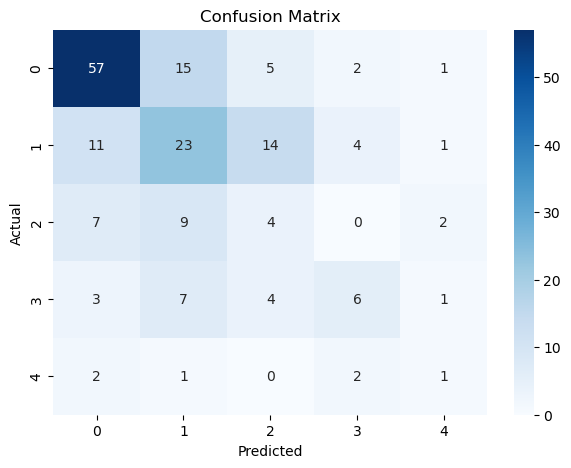

In [75]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC-AUC

In [76]:
y_prob = dt_model.predict_proba(X_test)
roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6522996282574065



Because this dataset has multiple possible num values, use the multiclass version:

**5.Hyperparameter Tuning**

Define parameter

In [77]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

Grid search cv

In [78]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(
    X_train,
    y_train
)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [80]:
print('best parameters:')
print(grid_search.best_params_)

best parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [81]:

print(
    'best cross-validation accuracy:',
    grid_search.best_score_
)

best cross-validation accuracy: 0.5682758620689654


In [84]:
best_model =grid_search.best_estimator_
print(best_model)

DecisionTreeClassifier(max_depth=3, random_state=42)


**6.Model Evaluation and Analysis**

In [85]:
y_pred_best=best_model.predict(X_test)

In [86]:
accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)
print("Final Accuracy:", accuracy_best)

Final Accuracy: 0.5054945054945055


In [87]:
precision_best = precision_score(
    y_test,
    y_pred_best,
    average='weighted',
    zero_division=0
)

recall_best = recall_score(
    y_test,
    y_pred_best,
    average='weighted',
    zero_division=0
)

f1_best = f1_score(
    y_test,
    y_pred_best,
    average='weighted',
    zero_division=0
)

print("Precision:", precision_best)
print("Recall:", recall_best)
print("F1 Score:", f1_best)

Precision: 0.4450970485453244
Recall: 0.5054945054945055
F1 Score: 0.47297774827186595


In [88]:
#final clsfn report
print(classification_report(
    y_test,
    y_pred_best,
    zero_division=0
)
)

              precision    recall  f1-score   support

           0       0.69      0.78      0.73        80
           1       0.38      0.42      0.40        53
           2       0.00      0.00      0.00        22
           3       0.28      0.38      0.32        21
           4       0.00      0.00      0.00         6

    accuracy                           0.51       182
   macro avg       0.27      0.31      0.29       182
weighted avg       0.45      0.51      0.47       182



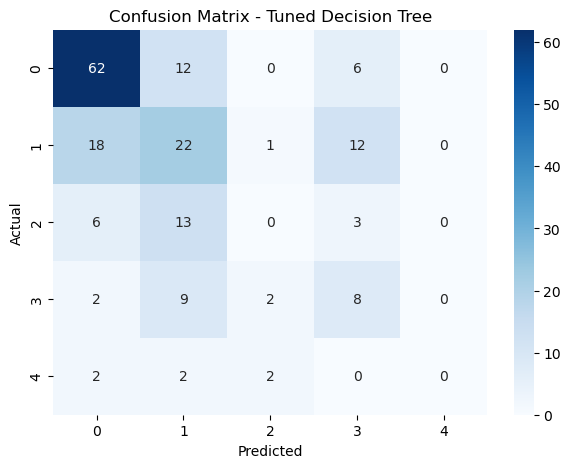

In [89]:
#final conclusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Decision Tree")

plt.show()

Visualize decision tree

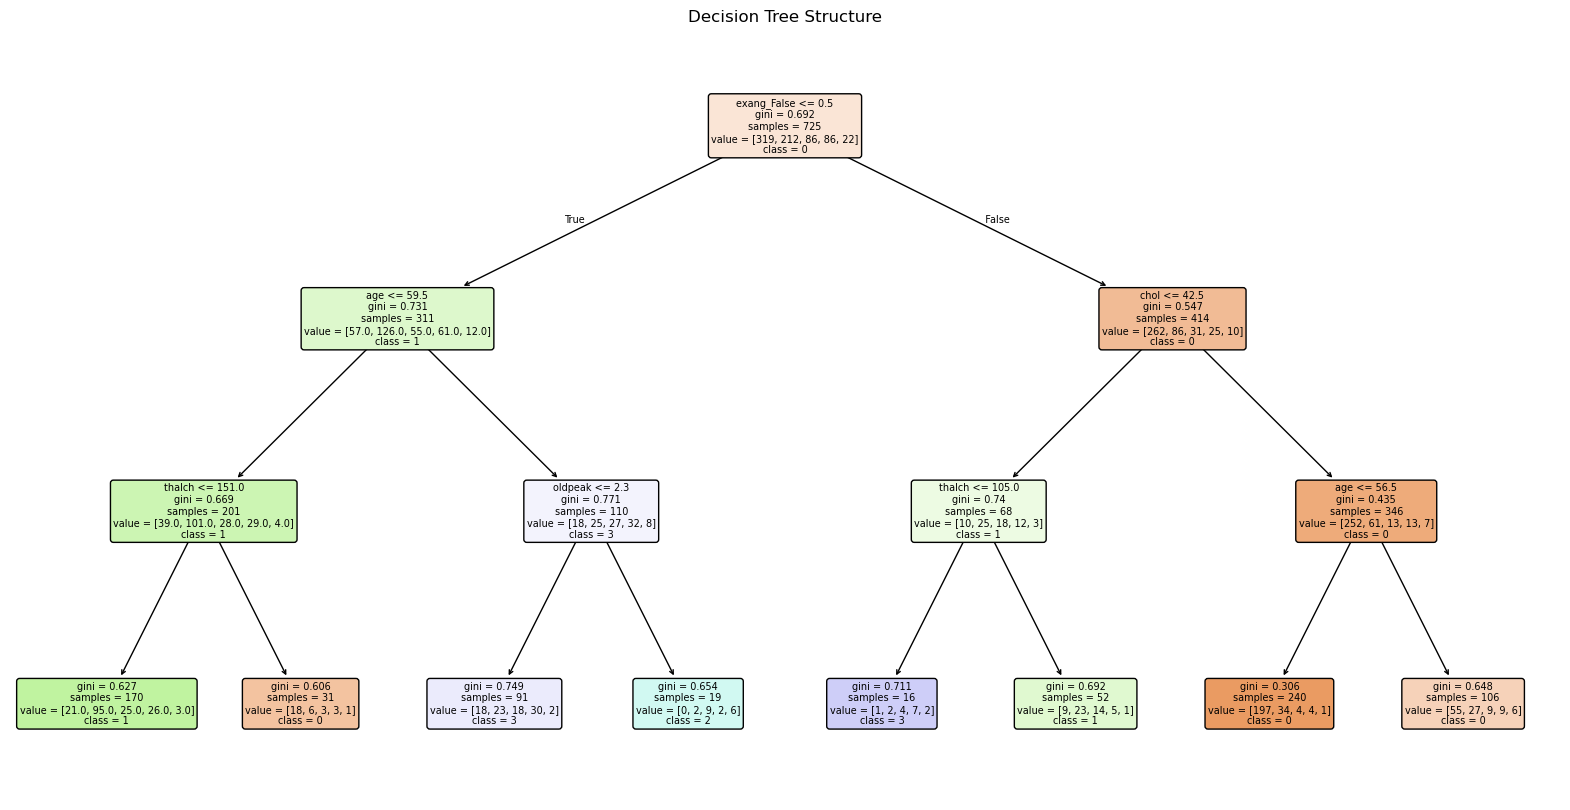

In [90]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[
        str(x) for x in sorted(y.unique())
    ],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree Structure")
plt.show()

In [91]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                     Feature  Importance
12               exang_False    0.451685
2                       chol    0.238622
0                        age    0.155449
3                     thalch    0.113742
4                    oldpeak    0.040503
11  restecg_st-t abnormality    0.000000
17               thal_normal    0.000000
16           slope_upsloping    0.000000
15                slope_flat    0.000000
14                exang_True    0.000000
13                exang_TURE    0.000000
9                   fbs_True    0.000000
10            restecg_normal    0.000000
1                   trestbps    0.000000
8          cp_typical angina    0.000000
7             cp_non-anginal    0.000000
6         cp_atypical angina    0.000000
5                   sex_Male    0.000000
18    thal_reversable defect    0.000000


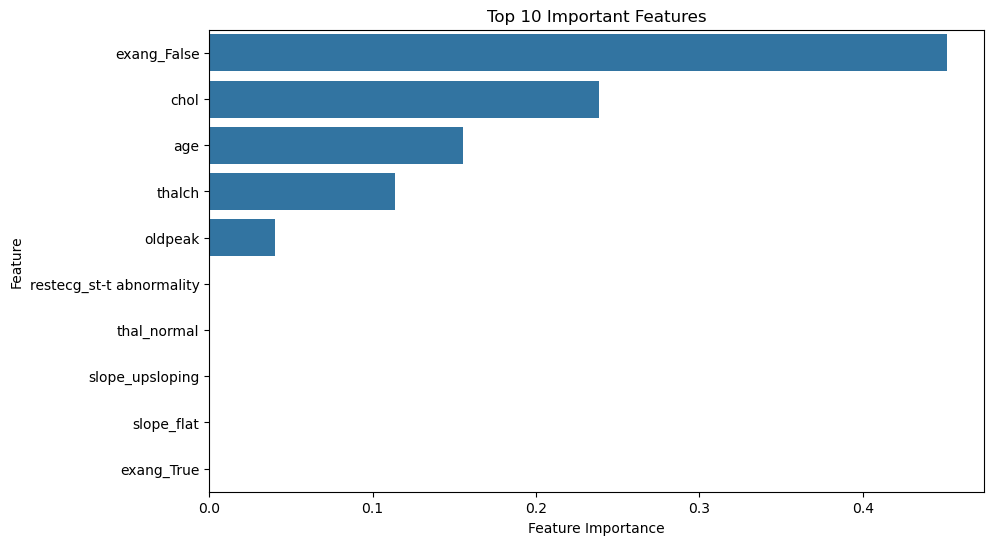

In [92]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)
plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

Model Evaluation and Analysis: The Decision Tree model was evaluated using accuracy, precision, recall, and F1-score. The confusion matrix was used to compare the actual and predicted classes. The decision tree visualization shows the rules learned by the model. Feature importance was calculated to identify the features that contributed most to the classification. Higher feature-importance values indicate that those features had a greater influence on the model's decisions.


**Interview questions**

1. What are some common hyperparameters of Decision Tree models, and how do they affect performance?
   
Common hyperparameters include max_depth, min_samples_split, min_samples_leaf, and criterion. They control the complexity of the tree and help reduce overfitting.

2. What is the difference between Label Encoding and One-Hot Encoding?
   
Label Encoding assigns a numerical value to each category, such as Male = 1 and Female = 0. One-Hot Encoding creates separate binary columns for each category. One-hot encoding is generally preferred for nominal categorical variables because it does not imply an artificial order between categories.